In [46]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [47]:
load_dotenv()

True

In [48]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [49]:
class JokeState(TypedDict):

    topic:str
    joke:str
    explanation:str

In [50]:
def joke_generation(state:JokeState):
    prompt=f"Generate a joke on {state['topic']}"
    response=llm.invoke(prompt).content
    return {'joke':response}

In [51]:
def joke_explanation(state:JokeState):
    prompt=f"Write an explanation for joke {state['joke']}"
    response=llm.invoke(prompt).content
    return {'explanation':response}

In [52]:
graph=StateGraph(JokeState)
graph.add_node("joke_generation",joke_generation)
graph.add_node("joke_explanation",joke_explanation)

In [53]:
graph.add_edge(START,"joke_generation")
graph.add_edge("joke_generation","joke_explanation")
graph.add_edge("joke_explanation",END)

In [54]:
checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

In [55]:
config={"configurable":{"thread_id":"1"}}

In [56]:
workflow.invoke({'topic':'FAST Univerity'},config)

{'topic': 'FAST Univerity',
 'joke': 'Here are a couple of jokes about FAST University:\n\n1.  "Why do FAST University students never struggle with slow internet?"\n    "Because they\'re used to processing information at an incredibly **FAST** pace, so everything else feels slow anyway!"\n\n2.  "What\'s a FAST University student\'s favorite type of debugging?"\n    "The kind that lets them finish their project **FAST** enough to catch an hour of sleep!"\n\n3.  "What\'s the university motto for FAST students?"\n    "Sleep is for the weak, coding is for the **FAST**!"',
 'explanation': 'These jokes cleverly play on the name "FAST University" by using the word "FAST" in its literal sense (speed, quickness) to describe aspects of the students\' lives and academic experience.\n\nHere\'s a breakdown of each joke:\n\n1.  **"Why do FAST University students never struggle with slow internet?"**\n    **"Because they\'re used to processing information at an incredibly FAST pace, so everything els

In [ ]:
workflow.get_state(config) #last value

StateSnapshot(values={'topic': 'FAST Univerity', 'joke': 'Here are a couple of jokes about FAST University:\n\n1.  "Why do FAST University students never struggle with slow internet?"\n    "Because they\'re used to processing information at an incredibly **FAST** pace, so everything else feels slow anyway!"\n\n2.  "What\'s a FAST University student\'s favorite type of debugging?"\n    "The kind that lets them finish their project **FAST** enough to catch an hour of sleep!"\n\n3.  "What\'s the university motto for FAST students?"\n    "Sleep is for the weak, coding is for the **FAST**!"', 'explanation': 'These jokes cleverly play on the name "FAST University" by using the word "FAST" in its literal sense (speed, quickness) to describe aspects of the students\' lives and academic experience.\n\nHere\'s a breakdown of each joke:\n\n1.  **"Why do FAST University students never struggle with slow internet?"**\n    **"Because they\'re used to processing information at an incredibly FAST pace

In [59]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'FAST Univerity', 'joke': 'Here are a couple of jokes about FAST University:\n\n1.  "Why do FAST University students never struggle with slow internet?"\n    "Because they\'re used to processing information at an incredibly **FAST** pace, so everything else feels slow anyway!"\n\n2.  "What\'s a FAST University student\'s favorite type of debugging?"\n    "The kind that lets them finish their project **FAST** enough to catch an hour of sleep!"\n\n3.  "What\'s the university motto for FAST students?"\n    "Sleep is for the weak, coding is for the **FAST**!"', 'explanation': 'These jokes cleverly play on the name "FAST University" by using the word "FAST" in its literal sense (speed, quickness) to describe aspects of the students\' lives and academic experience.\n\nHere\'s a breakdown of each joke:\n\n1.  **"Why do FAST University students never struggle with slow internet?"**\n    **"Because they\'re used to processing information at an incredibly FAST pac

In [ ]:
list

FAULT TOLERANCE


In [60]:
import time

In [61]:
class CrashState(TypedDict):
    input:str
    step1:str
    step2:str
    step3:str

In [62]:
def step_1(state:CrashState)->CrashState:
    print("Step 1 completed")
    return {"step1":"done","input":state["input"]}

In [63]:
def step_2(state:CrashState)->CrashState:
    print("Hanging")
    time.sleep(30)
    return {"step":"done"}

In [67]:
def step_3(state:CrashState)->CrashState:
    print("Step 3 completed")
    return {"step3":"done"}

In [68]:
graph=StateGraph(CrashState)
graph.add_node("step_1",step_1)
graph.add_node("step_2",step_2)
graph.add_node("step_3",step_3)

In [70]:
graph.add_edge(START,"step_1")
graph.add_edge("step_1","step_2")
graph.add_edge("step_2","step_3")
graph.add_edge("step_3",END)

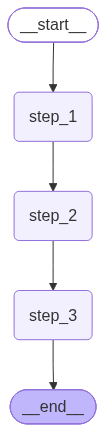

In [72]:
checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [ ]:
try:
    print("hello")
    workflow.invoke({"input":"start"},config={"configurable":{"thread_id":"thread1"}})
except KeyboardInterrupt:
    print("kenerl intepreped")

he;lo
Step 1 completed
Hanging


Step 3 completed


In [ ]:
print("")